In [3]:
import yfinance as yf

# 1. Fetch the data
ticker = "SO"
data = yf.download(ticker, start="2010-01-01", end="2024-01-01")

# 2. Save it to a CSV file in your project folder
data.to_csv("SO_historical_data.csv")

[*********************100%***********************]  1 of 1 completed


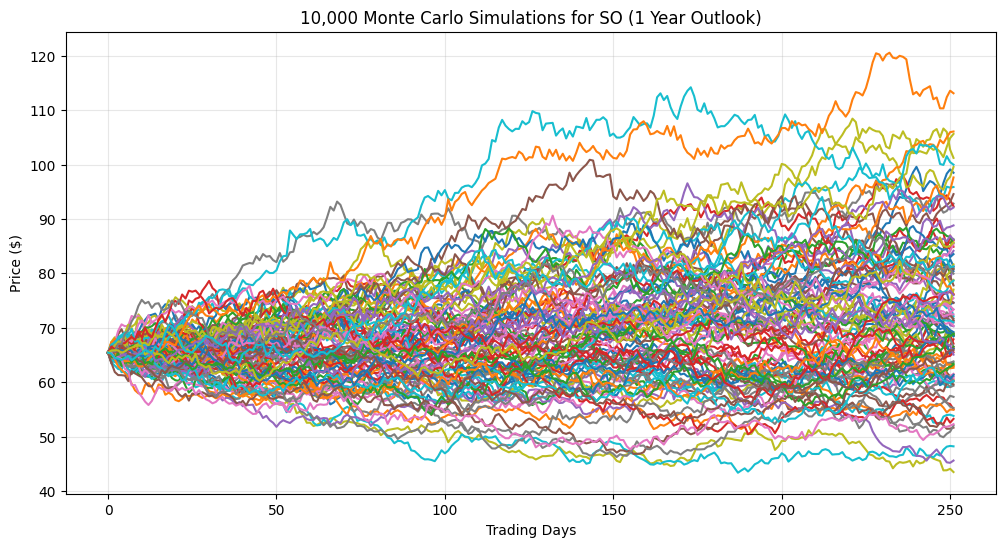

--- Simulation Results ---
Starting Price: $65.44
Target Price: $76.70
Probability of hitting or exceeding target: 33.72%
Mean Expected Price in 1 Year: $72.16


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Load Data
# We tell pandas that 'Date' is our index and to parse it as actual dates
df = pd.read_csv("SO_historical_data.csv", index_col='Date', parse_dates=True)

# 2. Calculate Log Returns
# We use the 'Close' column since 'Adj Close' is not in your file
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
log_returns = df['Log_Return'].dropna()

# 3. Extract Parameters for the Simulation
u = log_returns.mean()
var = log_returns.var()
stdev = log_returns.std()
drift = u - (0.5 * var)

# 4. Setup Simulation (1 Year / 10,000 Trials)
t_intervals = 252  # Typical trading days in a year
iterations = 10000
last_price = df['Close'].iloc[-1]

# 5. Generate Randomized Daily Returns (The "Monte Carlo" Engine)
daily_returns = np.exp(drift + stdev * norm.ppf(np.random.rand(t_intervals, iterations)))

# 6. Calculate Future Price Paths
price_paths = np.zeros_like(daily_returns)
price_paths[0] = last_price

for t in range(1, t_intervals):
    price_paths[t] = price_paths[t - 1] * daily_returns[t]

# 7. Visualization: The "Spider" Chart (First 100 paths)
plt.figure(figsize=(12,6))
plt.plot(price_paths[:, :100])
plt.title(f"10,000 Monte Carlo Simulations for SO (1 Year Outlook)")
plt.xlabel("Trading Days")
plt.ylabel("Price ($)")
plt.grid(True, alpha=0.3)
plt.show()

# 8. Probability Analysis
target_price = 76.70 # Your price target from the CFA report
final_prices = price_paths[-1]
prob_of_target = (final_prices > target_price).sum() / iterations

print(f"--- Simulation Results ---")
print(f"Starting Price: ${last_price:.2f}")
print(f"Target Price: ${target_price:.2f}")
print(f"Probability of hitting or exceeding target: {prob_of_target:.2%}")
print(f"Mean Expected Price in 1 Year: ${final_prices.mean():.2f}")